In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- SUA ESTRUTURA DE DIRETÓRIOS E CAPTURA ---
ROOT_DIR = "drive/MyDrive/heatmaps"  # Ajuste para a sua pasta raiz
patient_dict = {"Healthy": {}, "Sick": {}}
classes = ["Healthy", "Sick"]

for classe in classes:
    class_path = os.path.join(ROOT_DIR, classe)
    label = 0 if classe == "Healthy" else 1

    if not os.path.exists(class_path):
        continue

    for paciente in os.listdir(class_path):
        paciente_path = os.path.join(class_path, paciente)
        if not os.path.isdir(paciente_path):
            continue

        patient_images = []

        for visita in os.listdir(paciente_path):
            visita_path = os.path.join(paciente_path, visita, "images", "thermography")

            for modo in ["static", "dynamic"]:
                modo_path = os.path.join(visita_path, modo)
                if not os.path.exists(modo_path):
                    continue

                for file in os.listdir(modo_path):
                    if not file.lower().endswith(".jpg"):
                        continue

                    nome = os.path.splitext(file)[0]
                    partes = nome.split(".")

                    if len(partes) < 5:
                        continue

                    codigo = f"{partes[1]}.{partes[2]}"
                    if codigo != "1.1":
                        continue

                    image_path = os.path.join(modo_path, file)
                    patient_images.append((image_path, label))

        patient_dict[classe][paciente] = patient_images


In [ ]:
total_pacientes_healthy = len(patient_dict["Healthy"])
total_pacientes_sick = len(patient_dict["Sick"])

total_imagens_healthy = sum(len(fotos) for fotos in patient_dict["Healthy"].values())
total_imagens_sick = sum(len(fotos) for fotos in patient_dict["Sick"].values())

print("="*45)
print("   ESTATÍSTICAS DA BASE DE DADOS (ITEM 2.a)   ")
print("="*45)
print(f"Classe HEALTHY:")
print(f"  - Total de Pacientes Únicos: {total_pacientes_healthy}")
print(f"  - Total de Imagens Térmicas: {total_imagens_healthy}")
print(f"  - Média de imagens por paciente: {total_imagens_healthy/total_pacientes_healthy:.1f}" if total_pacientes_healthy > 0 else 0)
print("-"*45)
print(f"Classe SICK:")
print(f"  - Total de Pacientes Únicos: {total_pacientes_sick}")
print(f"  - Total de Imagens Térmicas: {total_imagens_sick}")
print(f"  - Média de imagens por paciente: {total_imagens_sick/total_pacientes_sick:.1f}" if total_pacientes_sick > 0 else 0)
print("="*45)
print(f"TOTAL GERAL: {total_pacientes_healthy + total_pacientes_sick} pacientes | {total_imagens_healthy + total_imagens_sick} imagens")
print("="*45)

   ESTATÍSTICAS DA BASE DE DADOS (ITEM 2.a)   
Classe HEALTHY:
  - Total de Pacientes Únicos: 192
  - Total de Imagens Térmicas: 3454
  - Média de imagens por paciente: 18.0
---------------------------------------------
Classe SICK:
  - Total de Pacientes Únicos: 46
  - Total de Imagens Térmicas: 790
  - Média de imagens por paciente: 17.2
TOTAL GERAL: 238 pacientes | 4244 imagens


In [ ]:
import torch
from torchvision import transforms

IMG_SIZE = 224

# Medias e desvios padrão oficiais do ImageNet
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([

    transforms.ToTensor(),

    transforms.RandomResizedCrop(size=(IMG_SIZE, IMG_SIZE), scale=(0.9, 1.0), ratio=(0.95, 1.05)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# 2. PIPELINE DE VALIDAÇÃO E TESTE
valid_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print("Pipelines de transformação criados com sucesso!")

Pipelines de transformação criados com sucesso!


In [ ]:
from PIL import Image

todas_imagens = []
todos_labels = []
todos_pacientes = []

for classe in ["Healthy", "Sick"]:
    for paciente, lista_imagens in patient_dict[classe].items():
        for img_path, label in lista_imagens:
            todas_imagens.append((img_path, label))
            todos_labels.append(label)
            todos_pacientes.append(paciente)

X_paths = np.array(todas_imagens)
y_labels = np.array(todos_labels)
groups_pacientes = np.array(todos_pacientes)

# A nova classe de Dataset adaptada para o K-Fold
class KFoldTermografiaDataset(torch.utils.data.Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.long)

master_train_dataset = KFoldTermografiaDataset(todas_imagens, transform=train_transforms)
master_val_dataset = KFoldTermografiaDataset(todas_imagens, transform=valid_transforms)

In [ ]:
from sklearn.model_selection import StratifiedGroupKFold
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score
import torch.nn as nn
import torch.optim as optim
import timm
import copy
from tqdm.auto import tqdm

todos_os_labels_gerais = []
todas_as_preds_gerais = []

sgkf = StratifiedGroupKFold(n_splits=5)
epochs_por_fold = 10
historico_dos_folds = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Iniciando Validação Cruzada (5-Fold)...")

for fold, (train_idx, val_idx) in enumerate(sgkf.split(X_paths, y_labels, groups_pacientes)):
    print(f"\n======== TREINANDO O FOLD {fold+1}/5 ========")

    train_subset = Subset(master_train_dataset, train_idx)
    val_subset = Subset(master_val_dataset, val_idx)

    labels_treino_fold = y_labels[train_idx]
    class_sample_count = np.array(
        [len(np.where(labels_treino_fold == t)[0]) for t in np.unique(labels_treino_fold)]
    )
    weight_por_classe = 1.0 / class_sample_count
    pesos_amostras = np.array([weight_por_classe[label] for label in labels_treino_fold])
    pesos_amostras = torch.DoubleTensor(pesos_amostras)

    sampler = WeightedRandomSampler(
        weights=pesos_amostras,
        num_samples=len(pesos_amostras),
        replacement=True
    )

    train_loader = DataLoader(train_subset, batch_size=16, sampler=sampler, num_workers=2)
    val_loader = DataLoader(val_subset, batch_size=16, shuffle=False, num_workers=2)

    class_weights = compute_class_weight('balanced', classes=np.unique(labels_treino_fold), y=labels_treino_fold)
    pesos_classes = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=pesos_classes)

    # CNN:
    model = timm.create_model('densenet121', pretrained=True, num_classes=2, drop_rate=0.3)

    model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=3e-5, weight_decay=0.1)

    fold_history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_recall_sick': []}

    best_acc = 0
    best_f1_sick = 0
    best_preds = None
    best_labels = None
    best_weights = None

    # Épocas
    for epoch in range(epochs_por_fold):

        preds_epoch = []
        labels_epoch = []

        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0

        pbar = tqdm(train_loader, desc=f"Fold {fold+1} | Epoch {epoch+1}")
        for imgs, labels in pbar:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            pbar.set_postfix(loss=loss.item())

            train_loss += loss.item() * imgs.size(0)
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * imgs.size(0)
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

                preds_epoch.extend(predicted.cpu().numpy())
                labels_epoch.extend(labels.cpu().numpy())

        val_acc = val_correct / val_total
        val_loss = val_loss / val_total
        train_loss = train_loss / train_total
        train_acc = train_correct / train_total

        f1_sick_epoch = f1_score(labels_epoch, preds_epoch, pos_label=1, zero_division=0)

        # --- Critério de melhor checkpoint
        if f1_sick_epoch > best_f1_sick:
          best_f1_sick = f1_sick_epoch
          best_acc = val_acc
          best_weights = copy.deepcopy(model.state_dict())
          best_preds = preds_epoch.copy()
          best_labels = labels_epoch.copy()

        fold_history['train_loss'].append(train_loss)
        fold_history['val_loss'].append(val_loss)
        fold_history['train_acc'].append(train_acc)
        fold_history['val_acc'].append(val_acc)
        fold_history['val_recall_sick'].append(f1_sick_epoch)

        print(f"  Epoch {epoch+1}: val_acc={val_acc*100:.1f}% | recall_sick={f1_sick_epoch*100:.1f}%")

    todas_as_preds_gerais.extend(best_preds)
    todos_os_labels_gerais.extend(best_labels)

    print(f"Fold {fold+1} Concluído! Melhor Recall Sick: {best_f1_sick*100:.1f}% (Acc correspondente: {best_acc*100:.1f}%)")
    historico_dos_folds.append(fold_history)
    print(f"Labels: {len(todos_os_labels_gerais)}")
    print(f"Preds: {len(todas_as_preds_gerais)}")

Iniciando Validação Cruzada (5-Fold)...

======== TREINANDO O FOLD 1/5 ========


Fold 1 | Epoch 1:   0%|          | 0/212 [00:00<?, ?it/s]

  Epoch 1: val_acc=73.8% | recall_sick=59.7%


Fold 1 | Epoch 2:   0%|          | 0/212 [00:00<?, ?it/s]

  Epoch 2: val_acc=83.0% | recall_sick=69.6%


...

  Epoch 8: val_acc=85.8% | recall_sick=32.0%


Fold 5 | Epoch 9:   0%|          | 0/213 [00:00<?, ?it/s]

  Epoch 9: val_acc=88.9% | recall_sick=54.2%


Fold 5 | Epoch 10:   0%|          | 0/213 [00:00<?, ?it/s]

  Epoch 10: val_acc=87.0% | recall_sick=41.1%
Fold 5 Concluído! Melhor Recall Sick: 66.9% (Acc correspondente: 89.3%)
Labels: 4244
Preds: 4244



       RELATORIO DE CLASSIFICAÇÃO       
              precision    recall  f1-score   support

     Healthy       0.93      0.89      0.91      3454
        Sick       0.59      0.72      0.65       790

    accuracy                           0.86      4244
   macro avg       0.76      0.80      0.78      4244
weighted avg       0.87      0.86      0.86      4244



<Axes: >

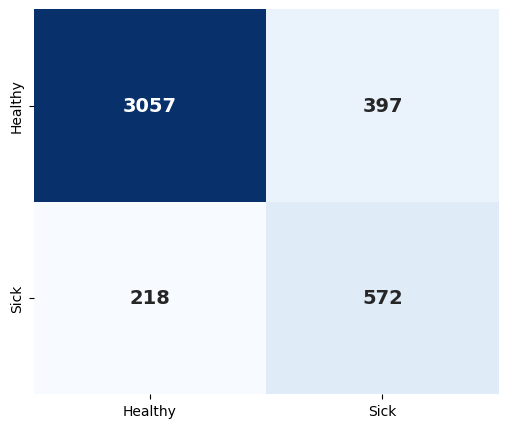

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("\n" + "="*60)
print("       RELATORIO DE CLASSIFICAÇÃO       ")
print("="*60)
print(classification_report(todos_os_labels_gerais, todas_as_preds_gerais, target_names=["Healthy", "Sick"]))
print("="*60)


plt.figure(figsize=(6, 5))
cm_consolidada = confusion_matrix(todos_os_labels_gerais, todas_as_preds_gerais)

sns.heatmap(cm_consolidada, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Healthy", "Sick"], yticklabels=["Healthy", "Sick"],
            cbar=False, annot_kws={"size": 14, "weight": "bold"})


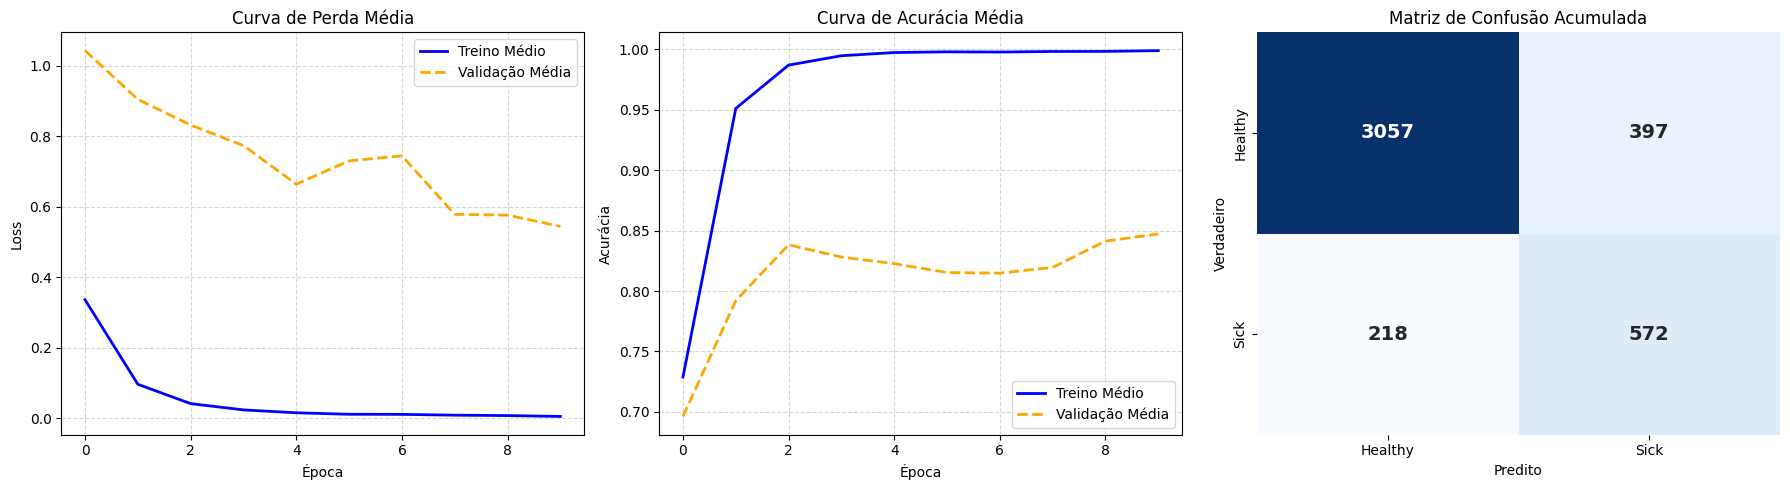

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Extrair e tirar a média das curvas de Loss e Acc de todos os 5 folds
num_epochs = len(historico_dos_folds[0]['train_loss'])

media_train_loss = np.mean([f['train_loss'] for f in historico_dos_folds], axis=0)
media_val_loss = np.mean([f['val_loss'] for f in historico_dos_folds], axis=0)
media_train_acc = np.mean([f['train_acc'] for f in historico_dos_folds], axis=0)
media_val_acc = np.mean([f['val_acc'] for f in historico_dos_folds], axis=0)

# 2. Configurar a figura tripla (igual à sua ideia original)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(media_train_loss, label='Treino Médio', color='blue', linewidth=2)
axes[0].plot(media_val_loss, label='Validação Média', color='orange', linewidth=2, linestyle='--')
axes[0].set_title('Curva de Perda Média')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Acurácia
axes[1].plot(media_train_acc, label='Treino Médio', color='blue', linewidth=2)
axes[1].plot(media_val_acc, label='Validação Média', color='orange', linewidth=2, linestyle='--')
axes[1].set_title('Curva de Acurácia Média')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Acurácia')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

# Matriz de Confusão
cm_consolidada = confusion_matrix(todos_os_labels_gerais, todas_as_preds_gerais)
sns.heatmap(cm_consolidada, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=["Healthy", "Sick"], yticklabels=["Healthy", "Sick"],
            cbar=False, annot_kws={"size": 14, "weight": "bold"})
axes[2].set_title('Matriz de Confusão Acumulada')
axes[2].set_xlabel('Predito')
axes[2].set_ylabel('Verdadeiro')

plt.tight_layout()
plt.show()